# Rank-based for finding the matching btw merfish cell to the snRNAseq cells
- do we also impute the original values?

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from scipy import stats
import scanpy as sc
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
import anndata

intersted_genes = ['Trhr','Pdyn','Tacr3','Shox2','Gpr101',]
markergenes = ['Dbh', 'Th', 'Slc6a2']


# load data

In [3]:
import glob, os, sys
from scipy.io import mmread
import sys
sys.path.append('../func/')
from imputations import *

In [4]:

filepath = '/allen/aind/scratch/shuonan.chen/LC_scRNAseq/conversion_files/'
f = glob.glob(filepath+'/*.h5ad')[1]
dataname = os.path.basename(f).split('.')[0]
targetfile = filepath + f'{dataname}.h5ad'    
targetfile_raw = filepath + f'RNA_counts_{dataname}.mtx'
adata_sc = sc.read_h5ad(targetfile)
adata_sc.layers['rawcounts'] = mmread(targetfile_raw).transpose().tocsr().astype('float64')    
adata_sc.X = adata_sc.layers['rawcounts']  
adata_sc.obs['sex'] = adata_sc.obs['sex'].replace({'M;M;M;M;M;M;M;M;M;M': 'M', 'F;F;F;F;F;F;F;F;F;F': 'F'})

/scratch/fast/45078/ipykernel_174498/2000313053.py:9: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_sc.obs['sex'] = adata_sc.obs['sex'].replace({'M;M;M;M;M;M;M;M;M;M': 'M', 'F;F;F;F;F;F;F;F;F;F': 'F'})


In [5]:
adata_sc.var["mt"] = adata_sc.var_names.str.startswith(("MT-","mt-"))
adata_sc.var["ribo"] = adata_sc.var_names.str.startswith(("RPS", "RPL",'rps','rpl'))
adata_sc.var["hb"] = adata_sc.var_names.str.contains("^HB[^(P)]")

print(adata_sc.var['mt'].sum(), adata_sc.var['ribo'].sum(), adata_sc.var['hb'].sum())

13 0 0


In [6]:
sc.pp.calculate_qc_metrics(
    adata_sc, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12040. The TBB threading layer is disabled.
  warnings.warn(problem)


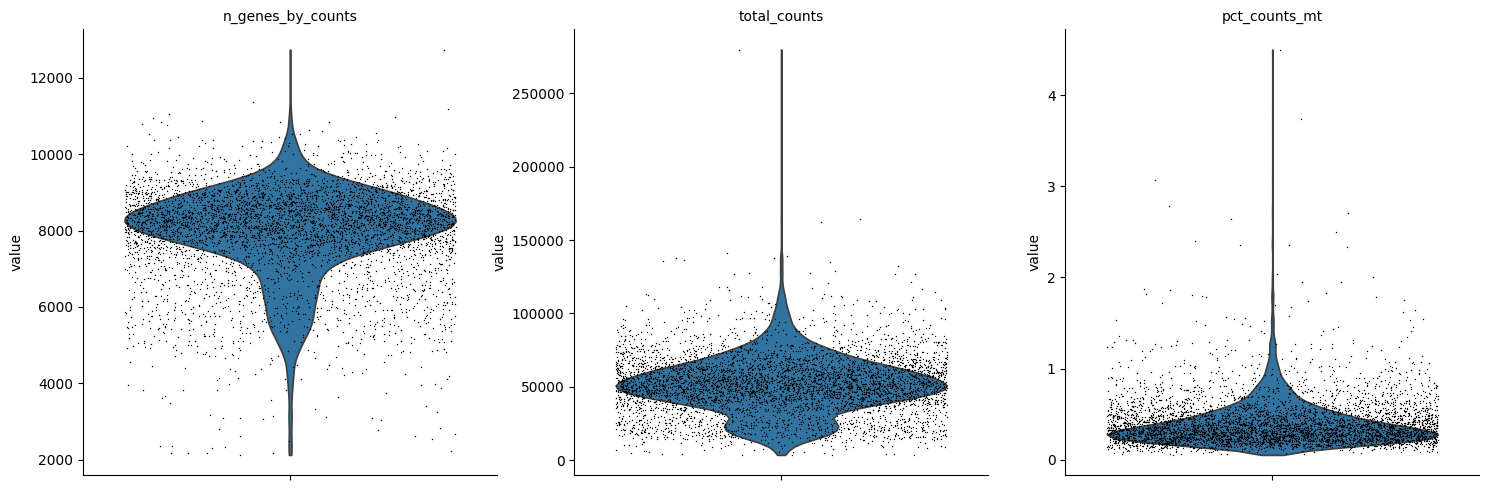

In [7]:
sc.pl.violin(
    adata_sc,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)


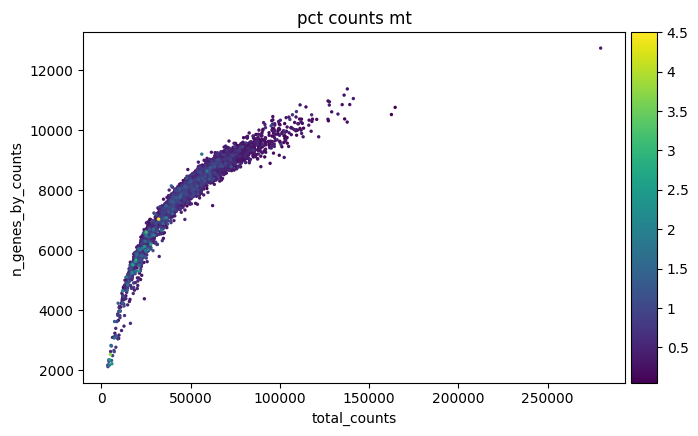

In [8]:
sc.pl.scatter(adata_sc, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [9]:
sc.pp.normalize_total(adata_sc)
sc.pp.log1p(adata_sc)

# load merfish too
(these are normalized already..?)

In [10]:
filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_3k.h5ad'
adata_mer = sc.read_h5ad(filename)
var_names = adata_mer.var_names.intersection(adata_sc.var_names)
adata_mer = adata_mer[:,var_names]  # 314 genes 

In [11]:
adata_mer.shape

(3227, 314)

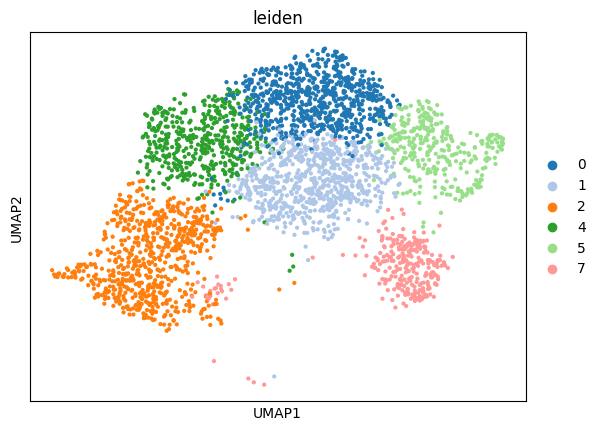

In [12]:
sc.pl.umap(adata_mer, color=['leiden',], )


### re-run the leiden for ONLY these 3k cells

In [13]:
sc.tl.pca(adata_mer)
sc.pp.neighbors(adata_mer)
sc.tl.umap(adata_mer, random_state=210)
sc.tl.leiden(adata_mer, resolution=1, key_added = 'new leiden!', random_state=224) 

/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:314: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
/scratch/fast/45078/ipykernel_174498/504708503.py:4: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_mer, resolution=1, key_added = 'new leiden!', random_state=224)


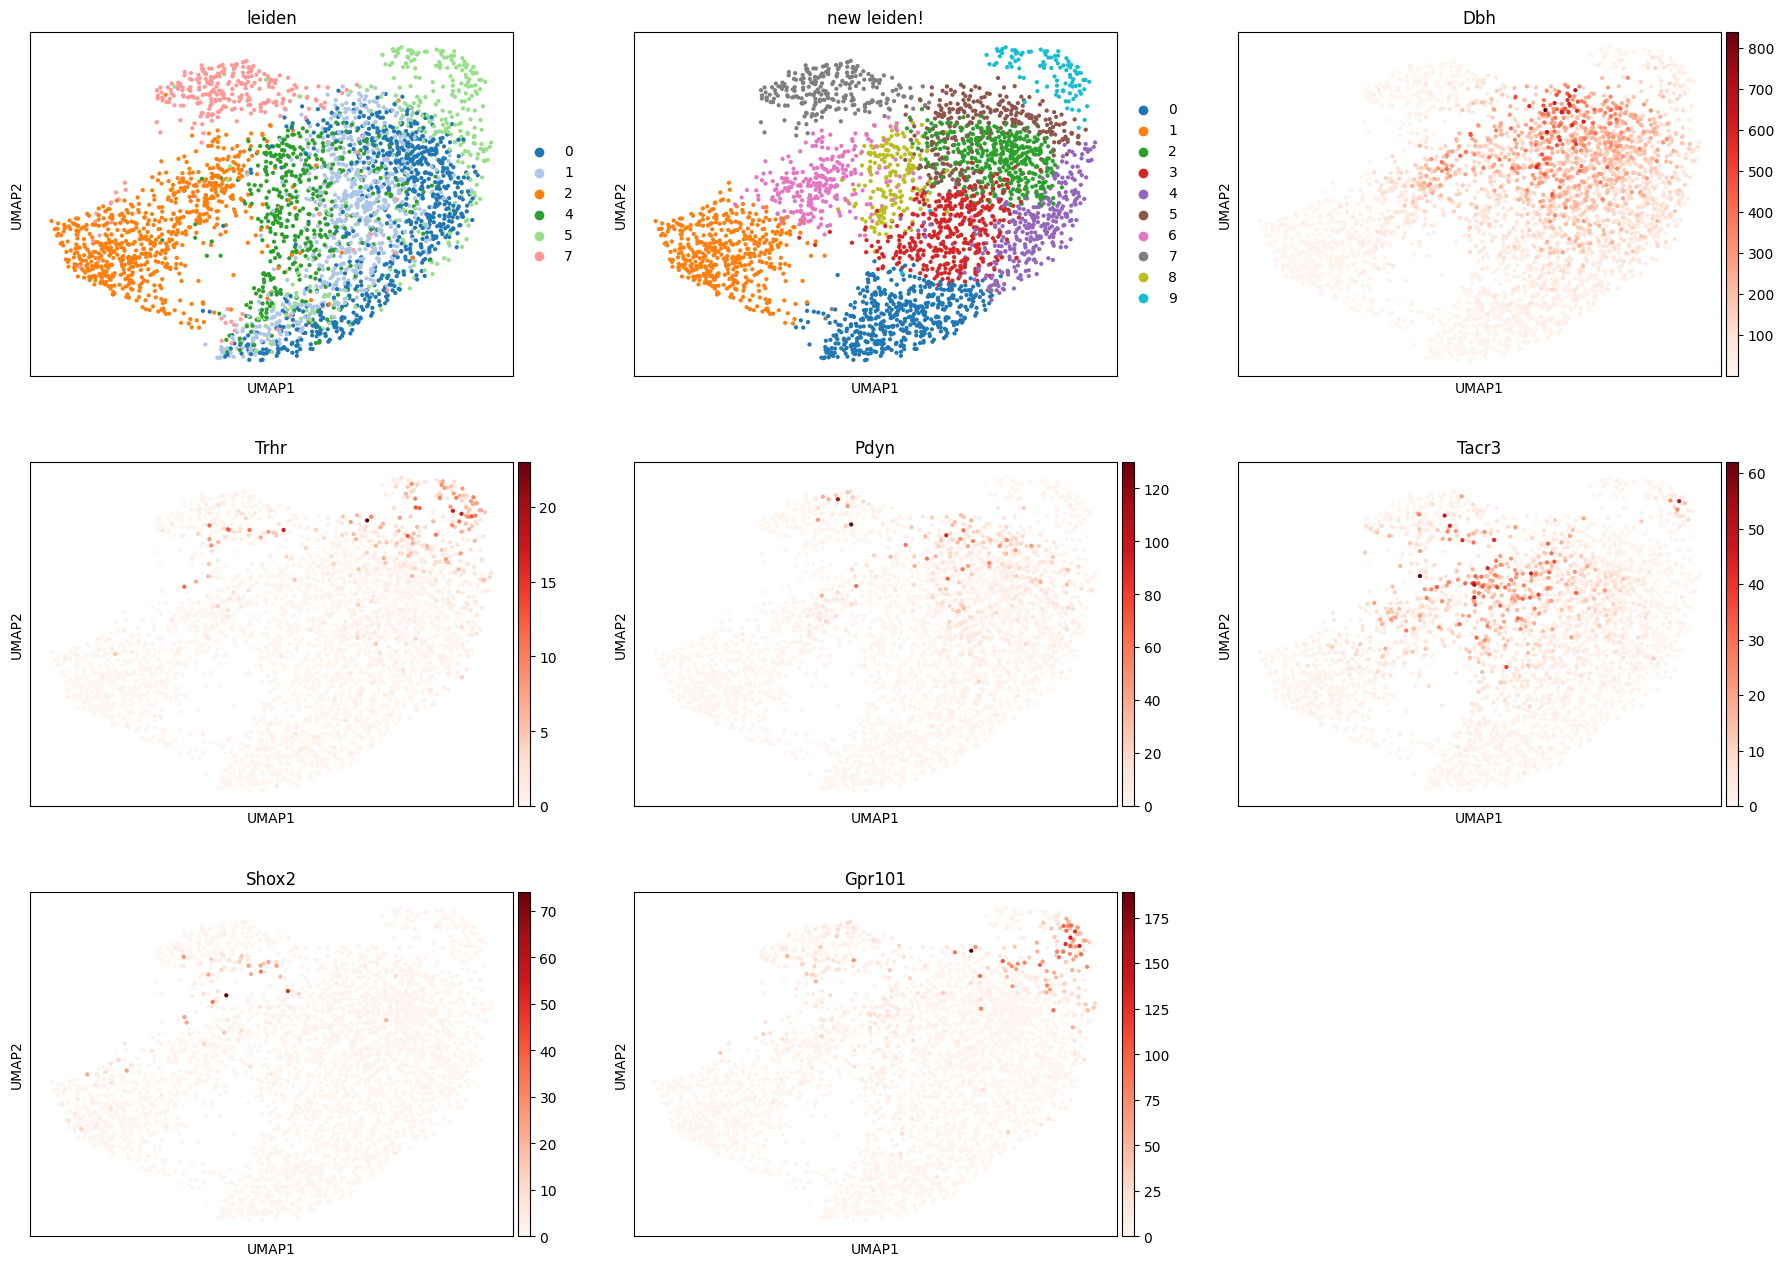

In [14]:
sc.pl.umap(adata_mer,color=['leiden', 'new leiden!',"Dbh"]+intersted_genes,cmap='Reds',ncols=3)

In [15]:
adata_mer.shape, adata_sc.shape

((3227, 314), (5040, 29617))

# RUN impute!

In [16]:

adata_mer_imputed = impute_mer_data(adata_sc, adata_mer, k=10, n_hvg=2000)

/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:75: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


# okay now we run teh clustering kind of thing

In [17]:
adata_mer_imputed.var_names

Index(['0610040J01Rik', '1110008E08Rik', '1110019D14Rik', '1600014C23Rik',
       '1700001C19Rik', '1700003L19Rik', '1700011B04Rik', '1700016H03Rik',
       '1700016P03Rik', '1700026D11Rik',
       ...
       'mt-Co1', 'mt-Co2', 'mt-Co3', 'mt-Cytb', 'mt-Nd1', 'mt-Nd2', 'mt-Nd3',
       'mt-Nd4', 'mt-Nd4l', 'mt-Nd5'],
      dtype='object', length=2149)

In [18]:
adata_mer_imputed.shape

(3227, 2149)

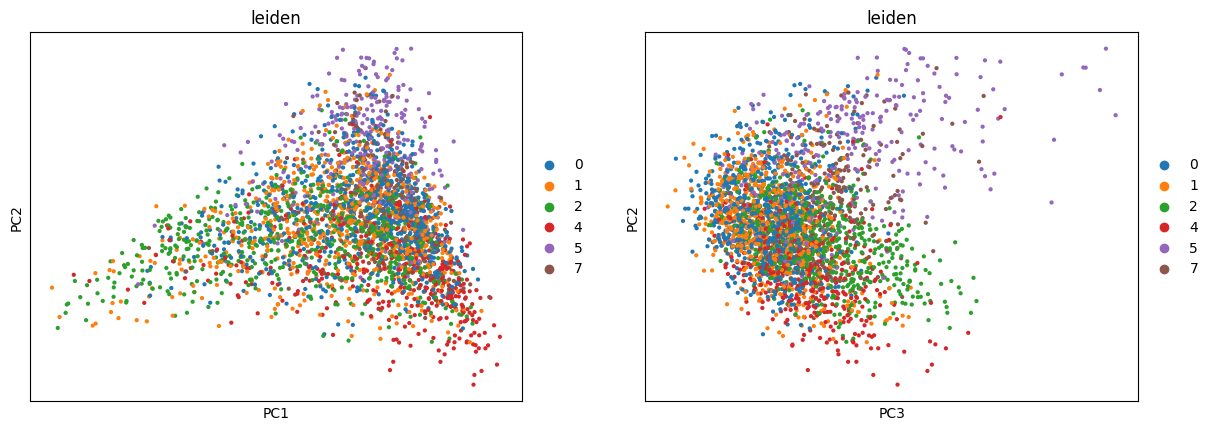

In [19]:
sc.tl.pca(adata_mer_imputed)
sc.pl.pca(adata_mer_imputed,color=['leiden','leiden'], dimensions = [(0,1),(2,1)])

In [20]:
adata_mer_imputed.varm

AxisArrays with keys: PCs

In [21]:
df_loadings = pd.DataFrame(adata_mer_imputed.varm['PCs'], index=adata_mer_imputed.var_names)

In [22]:
# top T genes with PC1.. 
T = 10
adata_mer_imputed.var_names[np.argsort(df_loadings[0])[::-1][:T]]  

Index(['Pcdh7', 'Zfp804b', 'Dach1', 'Ptprk', 'Xist', 'Luzp2', 'Gabrg3',
       'Glra2', 'Khdrbs2', 'Chsy3'],
      dtype='object')

In [23]:
adata_mer_imputed.shape

(3227, 2149)

In [24]:
import matplotlib.pyplot as plt

In [25]:
(adata_mer.X[:,adata_mer.var_names =='Dbh'] == adata_mer_imputed.X[:,adata_mer_imputed.var_names =='Dbh']).all()

np.False_

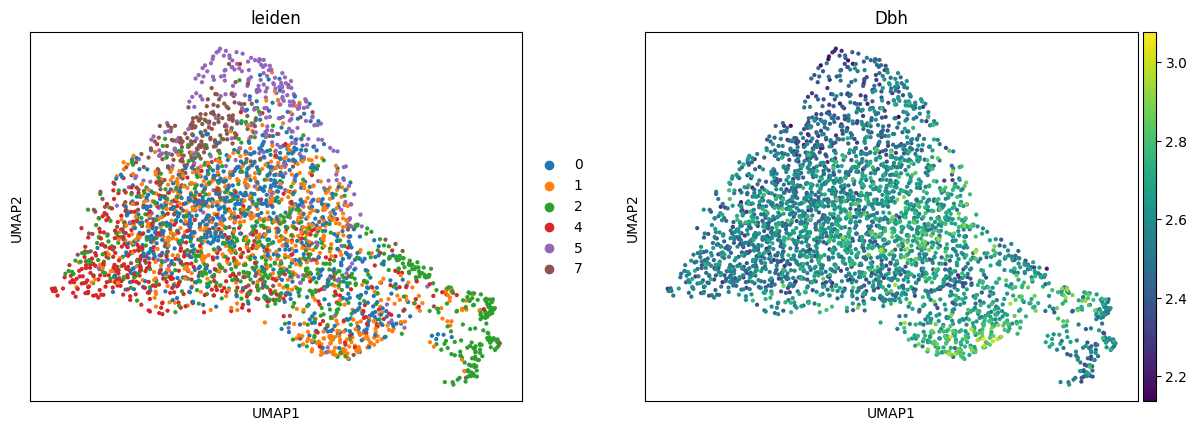

In [26]:

sc.pp.neighbors(adata_mer_imputed)
sc.tl.umap(adata_mer_imputed)
sc.pl.umap(adata_mer_imputed,color=["leiden",'Dbh'],)

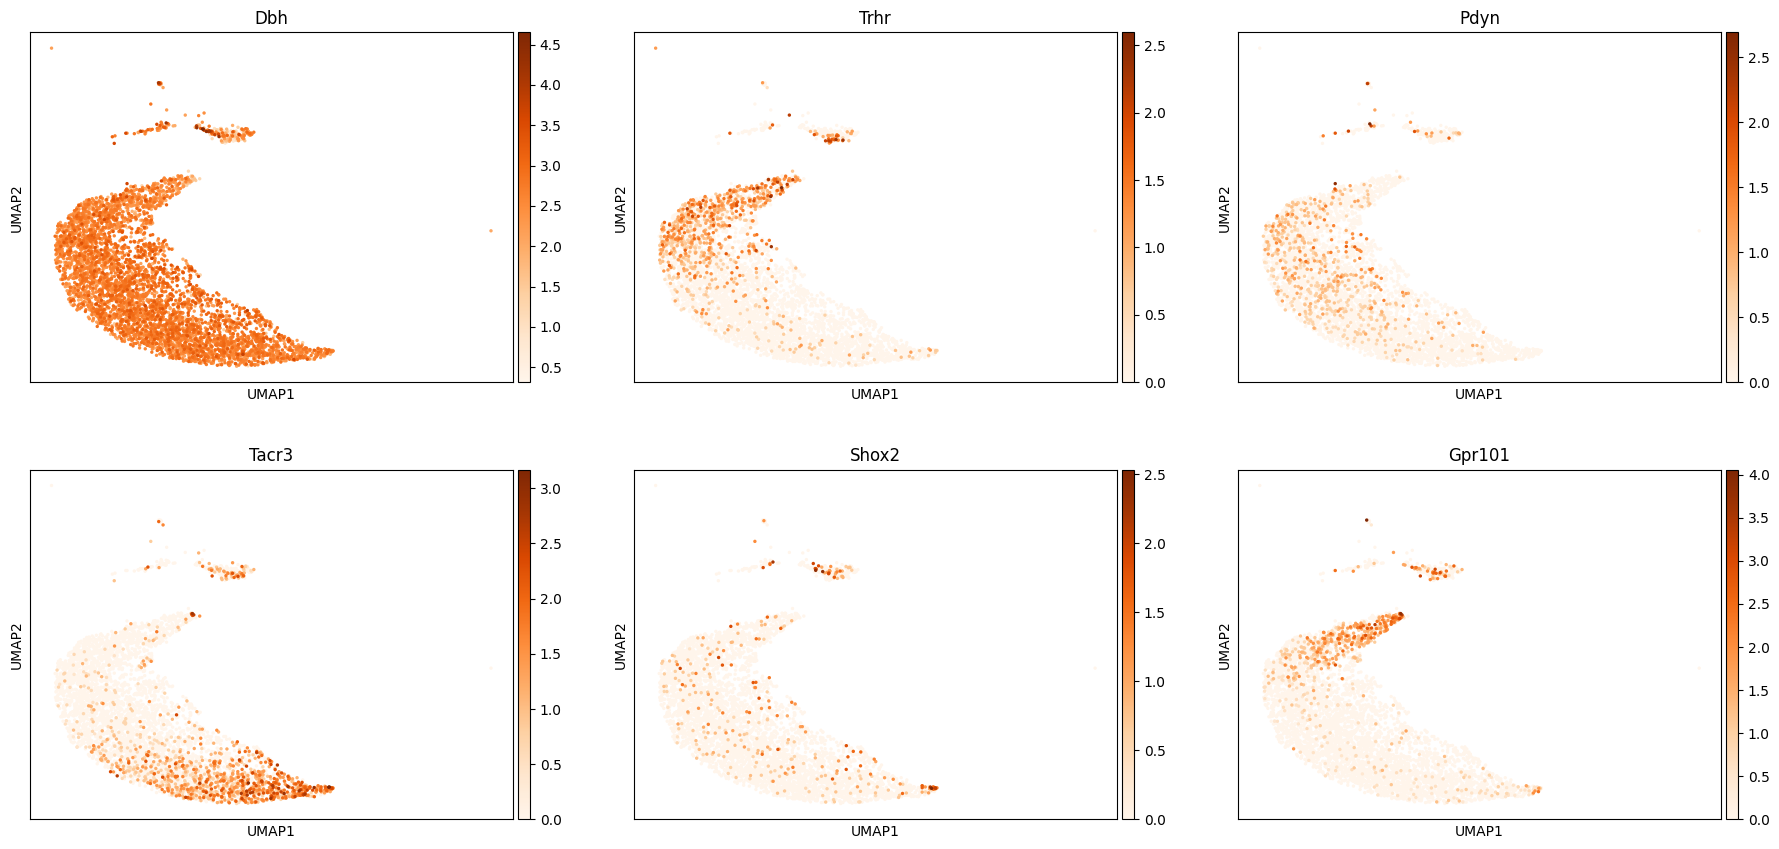

In [27]:
sc.pl.umap(adata_sc,color=["Dbh"]+intersted_genes,
           cmap='Oranges',ncols=3)

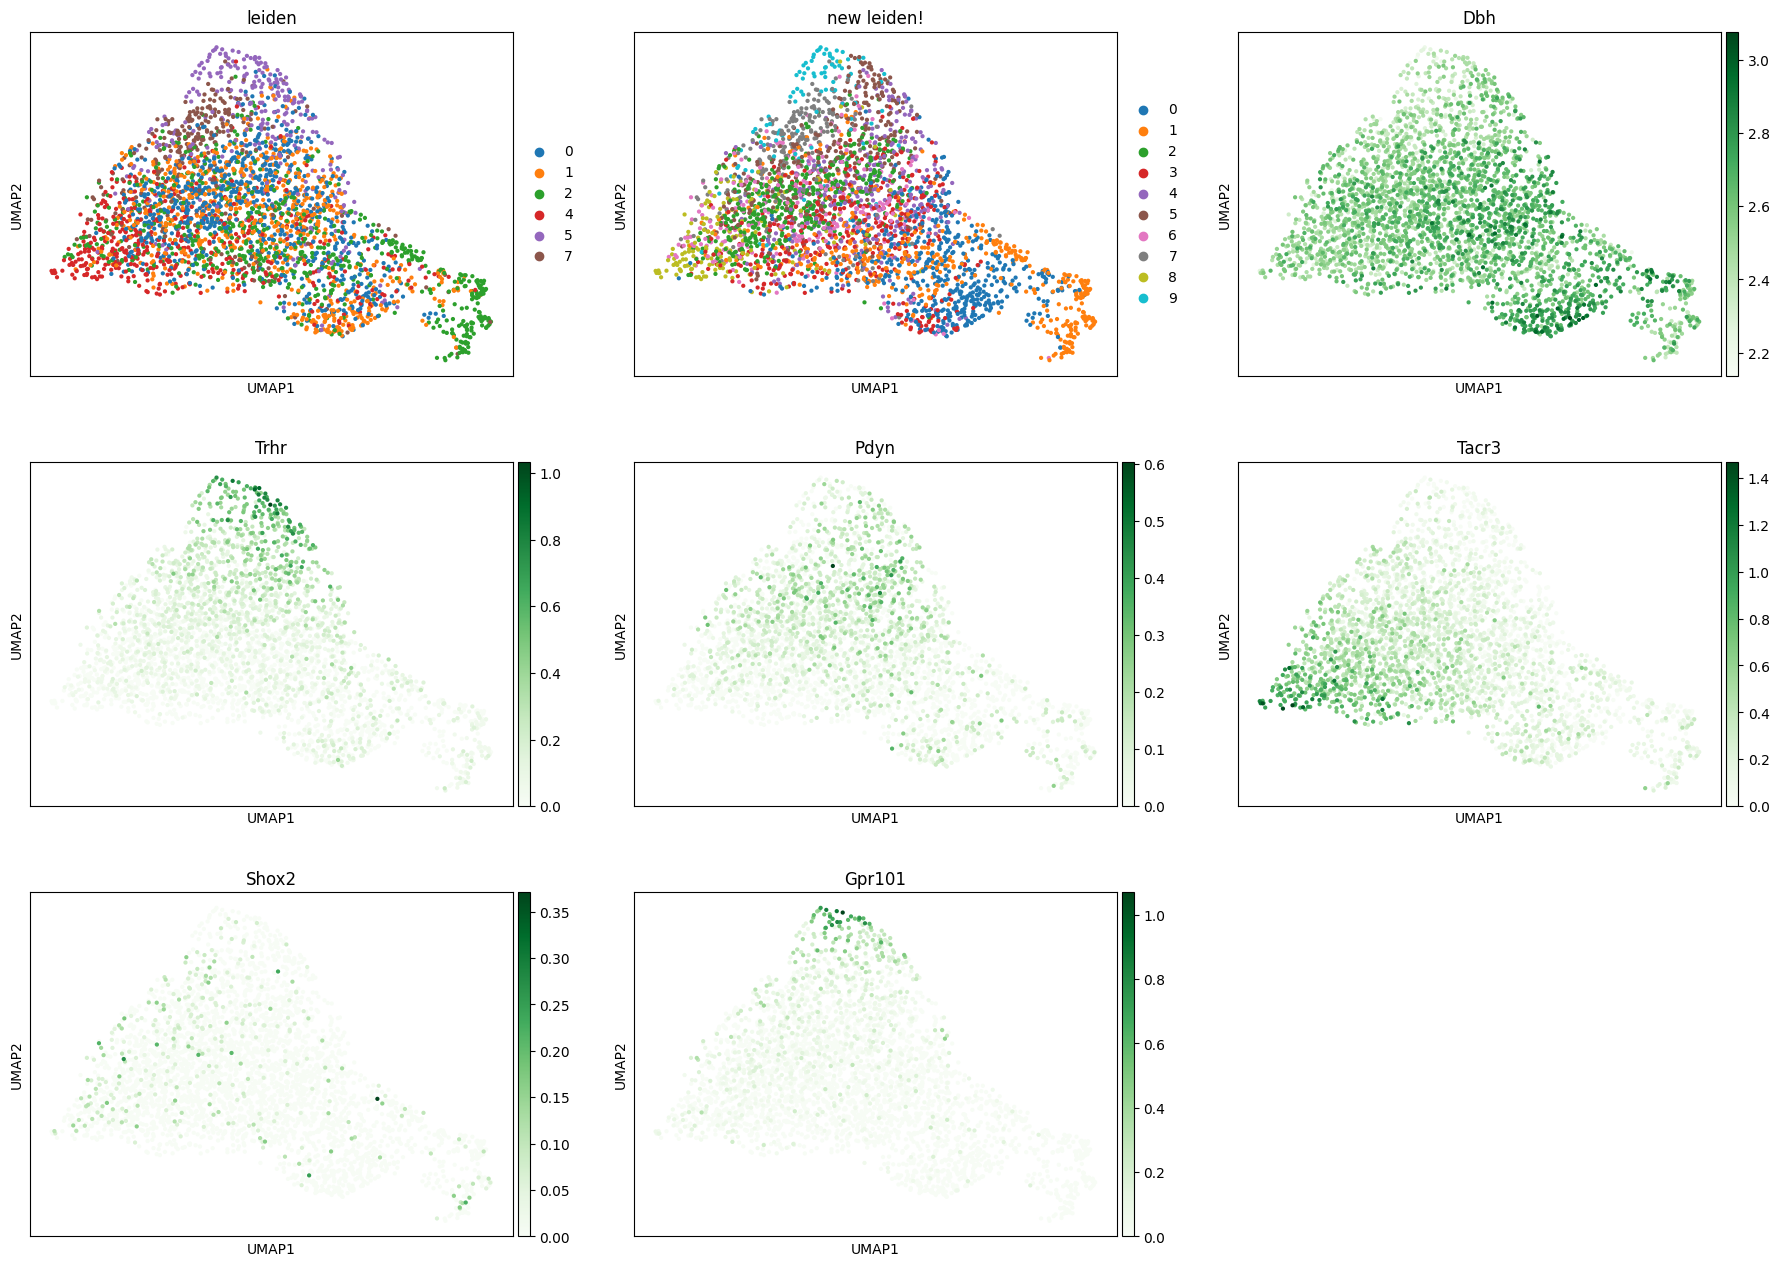

In [28]:
sc.pl.umap(adata_mer_imputed,color=['leiden', 'new leiden!',"Dbh"]+intersted_genes,
           cmap='Greens',ncols=3)

# so how to validate this imputation result? 
- note sure at this point

In [36]:
# confirm all the merfish genes are kept (it should be since we took the union)
np.array([(a in (adata_mer_imputed.var_names)) for a in (adata_mer.var_names)]).sum()

np.int64(314)

# check their spatial distributions

In [43]:
adata_mer_imputed.obsm['spatial'] = adata_mer.obsm['spatial']

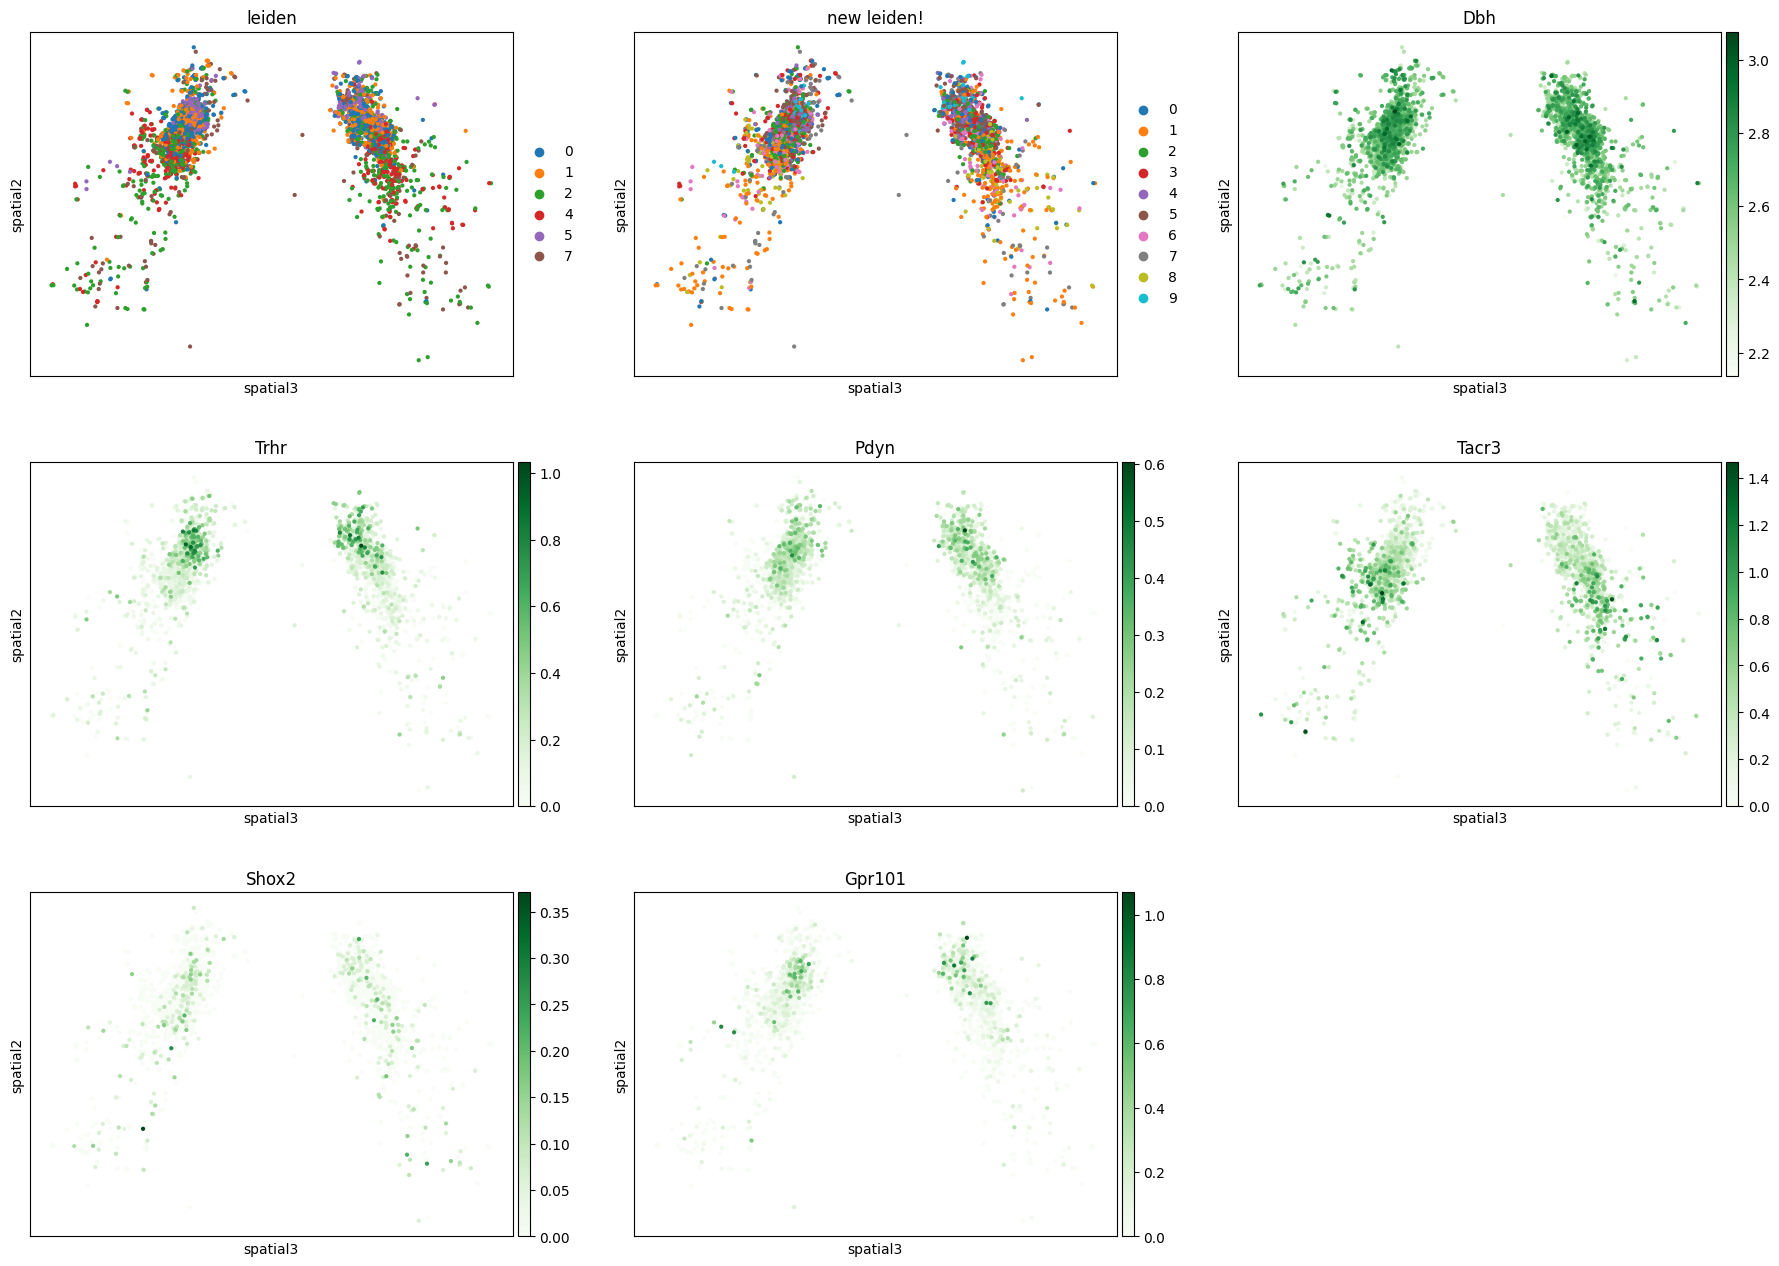

In [50]:
ax = sc.pl.embedding(adata_mer_imputed,basis='spatial',dimensions=(2,1),
                color=['leiden', 'new leiden!',"Dbh"]+intersted_genes,
           cmap='Greens',ncols=3, show = False)

for a in ax:
    a.invert_yaxis()
